# 04 —-Konačna evaluacija retrieval modela

U ovom notebook-u radimo konačnu evaluaciju izabranog modela na `test.pt` skupu.

Evaluacija sistema je predviđena za oba pravca:
- **Text → Image** — tekstualni opis → najrelevantnije slike
- **Image → Text** — slika → najrelevantniji tekstualni opisi


Evaluacija se radi na nivou clothing item-a, što znači da je rezultat tačan ako pronađeni uzorak pripada istom komadu odeće.


## 1. Učitavanje test skupa i modela

Koristimo postojeće test embeddinge iz `embeddings/test.pt` i izabrani model iz `embeddings/multimodal_model.pt`.

Embeddinge ne generišemo ponovo.


In [1]:
from pathlib import Path
import sys
import re
import random

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

cwd = Path.cwd().resolve()
PROJECT_ROOT = cwd.parent if cwd.name == "notebooks" else cwd
SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from vision_language_clothing_retrieval.retrieval.multimodal_retriever import (
    MultimodalRetriever,
)

TEST_PATH = PROJECT_ROOT / "embeddings" / "test.pt"
MODEL_PATH = PROJECT_ROOT / "embeddings" / "multimodal_model.pt"
RESULTS_DIR = PROJECT_ROOT / "embeddings" / "experiments"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = "cpu"
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

test_data = torch.load(TEST_PATH, weights_only=True)

image_embeddings = test_data["image_embeddings"]
text_embeddings = test_data["text_embeddings"]
sample_ids = test_data["sample_ids"]

retriever = MultimodalRetriever(
    model_path=str(MODEL_PATH),
    device=DEVICE,
)

print("Broj test uzoraka:", len(sample_ids))
print("Dimenzija image embeddinga:", tuple(image_embeddings.shape))
print("Dimenzija text embeddinga:", tuple(text_embeddings.shape))


Broj test uzoraka: 4116
Dimenzija image embeddinga: (4116, 512)
Dimenzija text embeddinga: (4116, 768)


## 2. Projektovanje embeddinga

Image i text embeddinge projektujemo u zajednički 256-dimenzionalni prostor.

Nakon toga koristimo cosine similarity za poređenje tekstualnih upita sa slikama.


In [2]:
with torch.no_grad():
    projected_images, projected_texts = retriever.project_embeddings(
        image_embeddings,
        text_embeddings,
    )

projected_images = F.normalize(projected_images, p=2, dim=1)
projected_texts = F.normalize(projected_texts, p=2, dim=1)

print("Projektovani image embeddingi:", tuple(projected_images.shape))
print("Projektovani text embeddingi:", tuple(projected_texts.shape))


Projektovani image embeddingi: (4116, 256)
Projektovani text embeddingi: (4116, 256)


## 3. Matrica sličnosti

Za svaki tekstualni upit računamo cosine similarity sa svim slikama.

Redovi matrice predstavljaju tekstualne upite, a kolone slike.


In [3]:
with torch.no_grad():
    similarity_matrix = projected_texts @ projected_images.T

print("Oblik matrice sličnosti:", tuple(similarity_matrix.shape))
print(
    "Raspon cosine similarity vrednosti:",
    round(float(similarity_matrix.min()), 4),
    "do",
    round(float(similarity_matrix.max()), 4),
)


Oblik matrice sličnosti: (4116, 4116)
Raspon cosine similarity vrednosti: -0.6284 do 0.7791


## 4. Identifikacija clothing item-a

Evaluacija se radi na nivou clothing item-a.

Iz `sample_id` izdvajamo ID komada odeće iz dela koji se nalazi nakon `-id_`.


In [4]:
def get_item_id(sample_id):
    sample_id = str(sample_id)
    match = re.search(r"-id_([^ -]+?)(?=-\d|$)", sample_id)

    if match:
        return match.group(1)

    if "-id_" in sample_id:
        return sample_id.split("-id_", 1)[1].split("-", 1)[0]

    return sample_id


item_ids = np.array([get_item_id(sample_id) for sample_id in sample_ids])

print("Primeri sample_id → item_id:")
for sample_id, item_id in zip(sample_ids[:5], item_ids[:5]):
    print(sample_id, "→", item_id)


Primeri sample_id → item_id:
MEN-Denim-id_00000938-02_1_front → 00000938
MEN-Denim-id_00000938-03_7_additional → 00000938
MEN-Denim-id_00000938-05_1_front → 00000938
MEN-Denim-id_00001223-01_4_full → 00001223
MEN-Denim-id_00002476-01_1_front → 00002476


## 5. Text → Image retrieval metrike

Za svaki tekstualni upit pronalazimo rang najbolje slike koja pripada istom clothing item-u.

Računamo:
- Recall@1
- Recall@5
- Recall@10
- MRR
- Mean Rank


In [5]:
def evaluate_text_to_image(similarities, item_ids):
    top_k = min(10, similarities.shape[1])

    top_scores, top_indices = torch.topk(
        similarities,
        k=top_k,
        dim=1,
    )

    ranks = []
    recall_hits = {1: 0, 5: 0, 10: 0}

    for query_index in range(similarities.shape[0]):
        query_item = item_ids[query_index]

        relevant_mask = item_ids == query_item
        relevant_scores = similarities[query_index][relevant_mask]

        best_relevant_score = relevant_scores.max()

        rank = int(
            (similarities[query_index] > best_relevant_score).sum().item()
        ) + 1

        ranks.append(rank)

        retrieved_items = item_ids[
            top_indices[query_index].cpu().numpy()
        ]

        for k in (1, 5, 10):
            if query_item in retrieved_items[:min(k, top_k)]:
                recall_hits[k] += 1

    ranks = np.array(ranks, dtype=np.float64)
    total = len(ranks)

    return {
        "recall@1": recall_hits[1] / total,
        "recall@5": recall_hits[5] / total,
        "recall@10": recall_hits[10] / total,
        "mrr": float(np.mean(1.0 / ranks)),
        "mean_rank": float(np.mean(ranks)),
        "ranks": ranks,
    }


text_to_image_results = evaluate_text_to_image(
    similarity_matrix,
    item_ids,
)

for name in ("recall@1", "recall@5", "recall@10", "mrr", "mean_rank"):
    print(f"{name}: {text_to_image_results[name]:.4f}")


recall@1: 0.0401
recall@5: 0.1229
recall@10: 0.1934
mrr: 0.0927
mean_rank: 183.3705


## 6. Konačna tabela rezultata

Glavne metrike za Text → Image pravac.


In [6]:
final_metrics = pd.DataFrame({
    "Metrika": [
        "Recall@1",
        "Recall@5",
        "Recall@10",
        "MRR",
        "Mean Rank",
    ],
    "Text → Image": [
        text_to_image_results["recall@1"],
        text_to_image_results["recall@5"],
        text_to_image_results["recall@10"],
        text_to_image_results["mrr"],
        text_to_image_results["mean_rank"],
    ],
})

final_metrics


,Metrika,Text → Image
0,Recall@1,0.040087
1,Recall@5,0.122935
2,Recall@10,0.193392
3,MRR,0.092705
4,Mean Rank,183.370505


## 7. Vizuelno poređenje metrika

Kod Recall i MRR veća vrednost je bolja, dok je kod Mean Rank-a manja vrednost bolja.


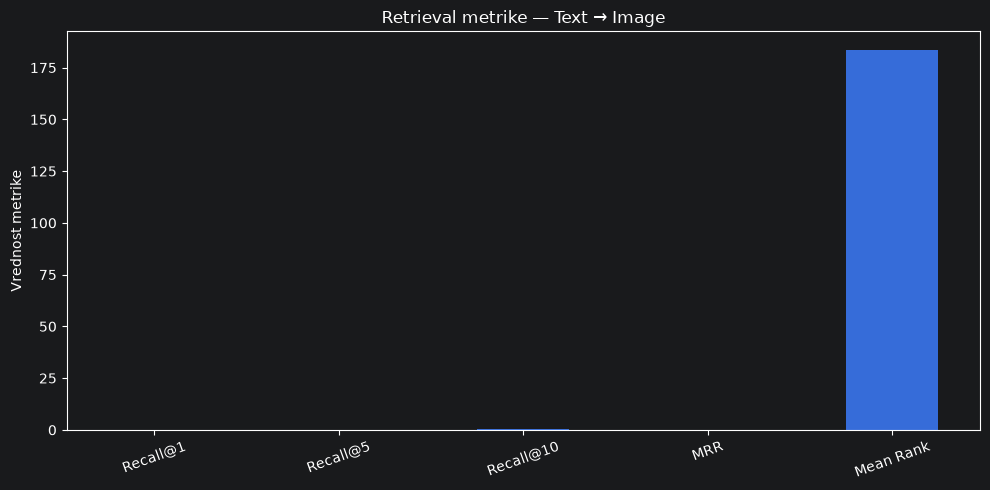

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(final_metrics))

ax.bar(
    x,
    final_metrics["Text → Image"],
    width=0.5,
)

ax.set_xticks(x)
ax.set_xticklabels(final_metrics["Metrika"], rotation=20)
ax.set_ylabel("Vrednost metrike")
ax.set_title("Retrieval metrike — Text → Image")

plt.tight_layout()
plt.show()


## 8. Distribucija rangova

Prikazujemo rang prvog relevantnog rezultata za svaki tekstualni upit.

Što je više rezultata na početku liste, to je model uspešniji u retrieval zadatku.


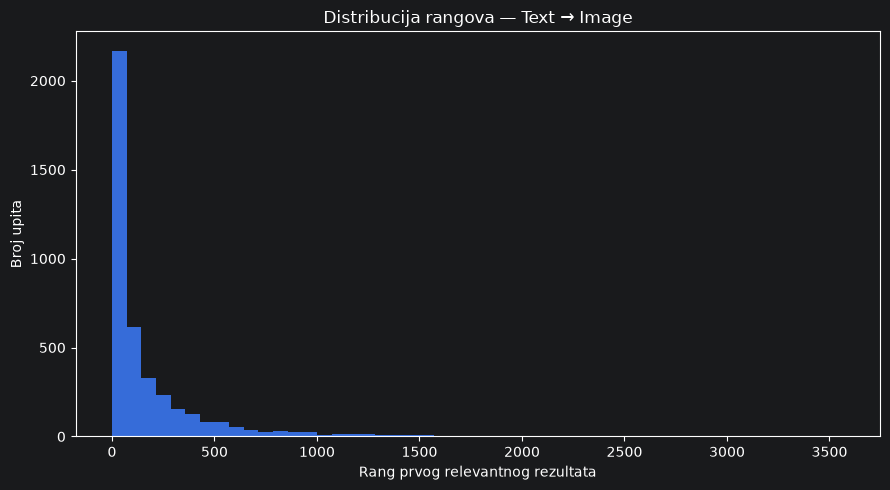

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(
    text_to_image_results["ranks"],
    bins=50,
)

ax.set_xlabel("Rang prvog relevantnog rezultata")
ax.set_ylabel("Broj upita")
ax.set_title("Distribucija rangova — Text → Image")

plt.tight_layout()
plt.show()


## 9. ROC kriva i AUC

ROC/AUC koristimo kao dodatnu analizu sposobnosti modela da razlikuje parove koji pripadaju istom clothing item-u od parova koji pripadaju različitim item-ima.

Ove metrike nisu zamena za retrieval metrike.


In [9]:
def build_text_to_image_pairs(similarities, item_ids, negative_count=100000):
    positive_scores = []
    negative_scores = []

    rng = np.random.default_rng(SEED)
    n = similarities.shape[0]

    for query_index in range(n):
        same_item = item_ids == item_ids[query_index]

        positive_scores.extend(
            similarities[query_index][same_item].cpu().numpy()
        )

        negative_indices = np.where(~same_item)[0]

        if len(negative_indices) > 0:
            count = min(
                len(negative_indices),
                max(1, negative_count // n),
            )
            selected = rng.choice(
                negative_indices,
                size=count,
                replace=False,
            )
            negative_scores.extend(
                similarities[query_index][selected].cpu().numpy()
            )

    scores = np.concatenate([
        np.asarray(positive_scores),
        np.asarray(negative_scores),
    ])

    labels = np.concatenate([
        np.ones(len(positive_scores), dtype=np.int8),
        np.zeros(len(negative_scores), dtype=np.int8),
    ])

    return scores, labels


t2i_scores, t2i_labels = build_text_to_image_pairs(
    similarity_matrix,
    item_ids,
)

print("Broj pozitivnih parova:", int(np.sum(t2i_labels == 1)))
print("Broj negativnih parova:", int(np.sum(t2i_labels == 0)))


Broj pozitivnih parova: 38024
Broj negativnih parova: 98784


In [10]:
def calculate_roc(scores, labels):
    order = np.argsort(scores)[::-1]

    sorted_scores = scores[order]
    sorted_labels = labels[order]

    true_positives = np.cumsum(sorted_labels == 1)
    false_positives = np.cumsum(sorted_labels == 0)

    total_positives = true_positives[-1]
    total_negatives = false_positives[-1]

    unique_positions = np.r_[
        np.where(np.diff(sorted_scores) != 0)[0],
        len(sorted_scores) - 1,
    ]

    tpr = true_positives[unique_positions] / total_positives
    fpr = false_positives[unique_positions] / total_negatives
    thresholds = sorted_scores[unique_positions]

    fpr = np.r_[0.0, fpr]
    tpr = np.r_[0.0, tpr]
    thresholds = np.r_[thresholds[0] + 1e-12, thresholds]

    auc_value = np.trapezoid(tpr, fpr)

    return fpr, tpr, thresholds, float(auc_value)


t2i_fpr, t2i_tpr, t2i_thresholds, t2i_auc = calculate_roc(
    t2i_scores,
    t2i_labels,
)

print("ROC AUC — Text → Image:", round(t2i_auc, 4))


ROC AUC — Text → Image: 0.7276


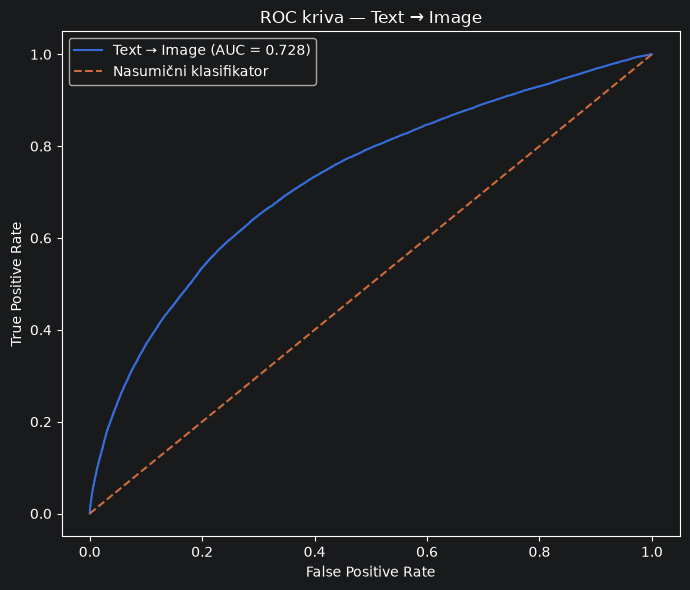

In [11]:
fig, ax = plt.subplots(figsize=(7, 6))

ax.plot(
    t2i_fpr,
    t2i_tpr,
    label=f"Text → Image (AUC = {t2i_auc:.3f})",
)

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Nasumični klasifikator",
)

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC kriva — Text → Image")
ax.legend()

plt.tight_layout()
plt.show()


## 10. Matrica konfuzije

Matrica konfuzije je pomoćna analiza. Prag biramo pomoću Youden-ovog kriterijuma na osnovu ROC krive.


In [12]:
def select_threshold(scores, labels):
    fpr, tpr, thresholds, _ = calculate_roc(scores, labels)
    best_index = np.argmax(tpr - fpr)
    return float(thresholds[best_index])


def confusion_matrix_values(scores, labels, threshold):
    predictions = scores >= threshold

    tp = int(np.sum(predictions & (labels == 1)))
    fp = int(np.sum(predictions & (labels == 0)))
    tn = int(np.sum(~predictions & (labels == 0)))
    fn = int(np.sum(~predictions & (labels == 1)))

    return np.array([
        [tn, fp],
        [fn, tp],
    ])


t2i_threshold = select_threshold(t2i_scores, t2i_labels)

t2i_cm = confusion_matrix_values(
    t2i_scores,
    t2i_labels,
    t2i_threshold,
)

print("Prag Text → Image:", round(t2i_threshold, 4))


Prag Text → Image: 0.3084


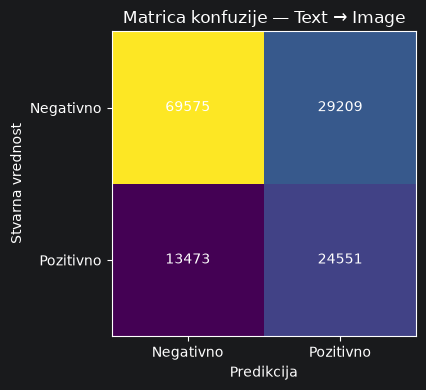

In [13]:
fig, ax = plt.subplots(figsize=(5, 4))

ax.imshow(t2i_cm)

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["Negativno", "Pozitivno"])
ax.set_yticklabels(["Negativno", "Pozitivno"])

ax.set_xlabel("Predikcija")
ax.set_ylabel("Stvarna vrednost")
ax.set_title("Matrica konfuzije — Text → Image")

for row in range(2):
    for column in range(2):
        ax.text(
            column,
            row,
            str(t2i_cm[row, column]),
            ha="center",
            va="center",
        )

plt.tight_layout()
plt.show()


## 11. Distribucija cosine similarity vrednosti

Upoređujemo similarity vrednosti pozitivnih i negativnih text-image parova.

Ako model dobro odvaja odgovarajuće parove, pozitivni parovi bi trebalo da imaju više similarity vrednosti.


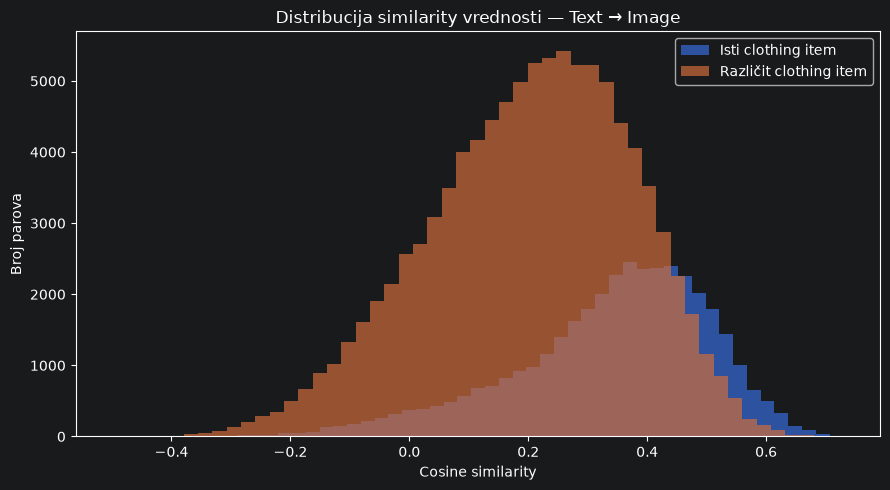

In [14]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(
    t2i_scores[t2i_labels == 1],
    bins=50,
    alpha=0.7,
    label="Isti clothing item",
)

ax.hist(
    t2i_scores[t2i_labels == 0],
    bins=50,
    alpha=0.7,
    label="Različit clothing item",
)

ax.set_xlabel("Cosine similarity")
ax.set_ylabel("Broj parova")
ax.set_title("Distribucija similarity vrednosti — Text → Image")
ax.legend()

plt.tight_layout()
plt.show()


## 12. Primeri retrieval rezultata

Prikazujemo nekoliko tekstualnih upita i prvih 5 pronađenih slika.

Pošto `test.pt` sadrži embeddinge i `sample_id` vrednosti, rezultate prikazujemo preko identifikatora i similarity skora.


In [15]:
def show_text_to_image_examples(
    similarities,
    sample_ids,
    item_ids,
    number_of_examples=5,
    top_k=5,
):
    for query_index in range(min(number_of_examples, len(sample_ids))):
        scores, indices = torch.topk(
            similarities[query_index],
            k=top_k,
        )

        print("\nTekstualni upit:", sample_ids[query_index])
        print("Item ID:", item_ids[query_index])
        print("Pronađene slike:")

        for rank, (index, score) in enumerate(
            zip(indices.tolist(), scores.tolist()),
            start=1,
        ):
            correct = item_ids[index] == item_ids[query_index]

            print(
                f"{rank}. {sample_ids[index]} | "
                f"score={score:.4f} | "
                f"isti item={correct}"
            )


show_text_to_image_examples(
    similarity_matrix,
    sample_ids,
    item_ids,
)



Tekstualni upit: MEN-Denim-id_00000938-02_1_front
Item ID: 00000938
Pronađene slike:
1. MEN-Tees_Tanks-id_00007365-01_7_additional | score=0.6488 | isti item=False
2. MEN-Denim-id_00003341-01_7_additional | score=0.6390 | isti item=False
3. MEN-Sweatshirts_Hoodies-id_00005104-01_4_full | score=0.6366 | isti item=False
4. MEN-Tees_Tanks-id_00002371-03_4_full | score=0.6282 | isti item=False
5. MEN-Sweaters-id_00007090-02_7_additional | score=0.6259 | isti item=False

Tekstualni upit: MEN-Denim-id_00000938-03_7_additional
Item ID: 00000938
Pronađene slike:
1. MEN-Denim-id_00003341-01_7_additional | score=0.6612 | isti item=False
2. MEN-Sweatshirts_Hoodies-id_00007613-01_4_full | score=0.6200 | isti item=False
3. MEN-Sweatshirts_Hoodies-id_00003153-01_4_full | score=0.6091 | isti item=False
4. MEN-Pants-id_00006292-06_4_full | score=0.6069 | isti item=False
5. MEN-Shorts-id_00000816-01_7_additional | score=0.5943 | isti item=False

Tekstualni upit: MEN-Denim-id_00000938-05_1_front
Item I

## 13. Čuvanje rezultata

Konačne Text → Image metrike čuvamo u CSV fajlu.


In [16]:
summary_results = pd.DataFrame([{
    "model": "Baseline",
    "text_to_image_recall_at_1": text_to_image_results["recall@1"],
    "text_to_image_recall_at_5": text_to_image_results["recall@5"],
    "text_to_image_recall_at_10": text_to_image_results["recall@10"],
    "text_to_image_mrr": text_to_image_results["mrr"],
    "text_to_image_mean_rank": text_to_image_results["mean_rank"],
    "text_to_image_roc_auc": t2i_auc,
}])

summary_results.to_csv(
    RESULTS_DIR / "final_test_text_to_image_results.csv",
    index=False,
)

summary_results


,model,text_to_image_recall_at_1,text_to_image_recall_at_5,text_to_image_recall_at_10,text_to_image_mrr,text_to_image_mean_rank,text_to_image_roc_auc
0,Baseline,0.040087,0.122935,0.193392,0.092705,183.370505,0.727562
